# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [1]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [2]:
# Load in the general demographics data.
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')

# Load in the feature summary file.
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [3]:
# Check the structure of the data after it's loaded
# rows and columns
azdias.shape

(891221, 85)

In [4]:
# check columns and first rows
azdias.head(3)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0


In [5]:
# check columns
azdias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-nu

In [6]:
# show columns and rows
feat_info.head(3)

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"


In [7]:
# columns and rows
feat_info.shape

(85, 4)

In [8]:
# check columns 
feat_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   attribute           85 non-null     object
 1   information_level   85 non-null     object
 2   type                85 non-null     object
 3   missing_or_unknown  85 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [9]:
# Identify missing or unknown data values and convert them to NaNs.

# sum of null values in df
azdias.isnull().sum().sum()

4896838

In [10]:
# placeholders for missing data
unknown_values = [-1, -999, 999, 9999, 'unknown', 'Unknown', 'UNKNOWN', 
                  'NA', 'N/A', 'n/a', 'null', 'NULL', '', ' ', '?', 'X', 'XX', 'XXX']

# check if unknown_values exists in dataset
for col in azdias.columns:
    unique_vals = azdias[col].unique()
    for uv in unknown_values:
        if uv in unique_vals:
            print(f"Column '{col}' contains placeholder: {uv}")

Column 'AGER_TYP' contains placeholder: -1
Column 'HEALTH_TYP' contains placeholder: -1
Column 'SHOPPER_TYP' contains placeholder: -1
Column 'VERS_TYP' contains placeholder: -1
Column 'CAMEO_DEUG_2015' contains placeholder: X
Column 'CAMEO_DEU_2015' contains placeholder: XX
Column 'CAMEO_INTL_2015' contains placeholder: XX
Column 'KBA13_ANZAHL_PKW' contains placeholder: 999


In [11]:
# replace unknown values with NaN
azdias.replace(unknown_values, np.nan, inplace=True)

In [12]:
# sum of null values in df after cleaning
azdias.isnull().sum().sum()

5909332

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [13]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

# check for null values in columns
azdias.isnull().sum()

AGER_TYP                 677503
ALTERSKATEGORIE_GROB          0
ANREDE_KZ                     0
CJT_GESAMTTYP              4854
FINANZ_MINIMALIST             0
FINANZ_SPARER                 0
FINANZ_VORSORGER              0
FINANZ_ANLEGER                0
FINANZ_UNAUFFAELLIGER         0
FINANZ_HAUSBAUER              0
FINANZTYP                     0
GEBURTSJAHR                   0
GFK_URLAUBERTYP            4854
GREEN_AVANTGARDE              0
HEALTH_TYP               111196
LP_LEBENSPHASE_FEIN        4854
LP_LEBENSPHASE_GROB        4854
LP_FAMILIE_FEIN            4854
LP_FAMILIE_GROB            4854
LP_STATUS_FEIN             4854
LP_STATUS_GROB             4854
NATIONALITAET_KZ              0
PRAEGENDE_JUGENDJAHRE         0
RETOURTYP_BK_S             4854
SEMIO_SOZ                     0
SEMIO_FAM                     0
SEMIO_REL                     0
SEMIO_MAT                     0
SEMIO_VERT                    0
SEMIO_LUST                    0
SEMIO_ERL                     0
SEMIO_KU

In [14]:
# check for null values in columns
feat_info.isnull().sum()

attribute             0
information_level     0
type                  0
missing_or_unknown    0
dtype: int64

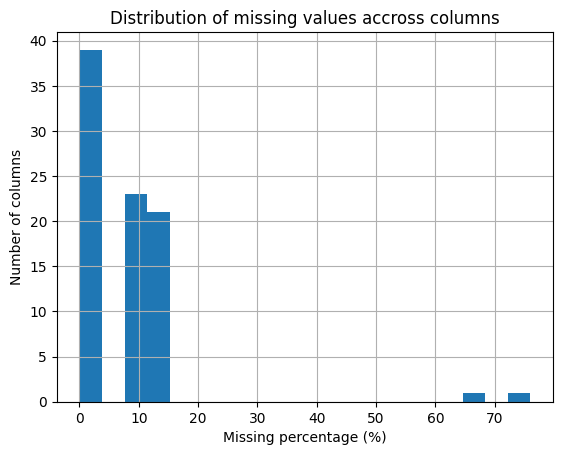

In [15]:
# Investigate patterns in the amount of missing data in each column.

# percentage of missing values per column
missing_pct = (azdias.isnull().sum() / len(azdias)) * 100
missing_pct.hist(bins=20)
plt.xlabel('Missing percentage (%)')
plt.ylabel('Number of columns')
plt.title('Distribution of missing values accross columns')
plt.show()

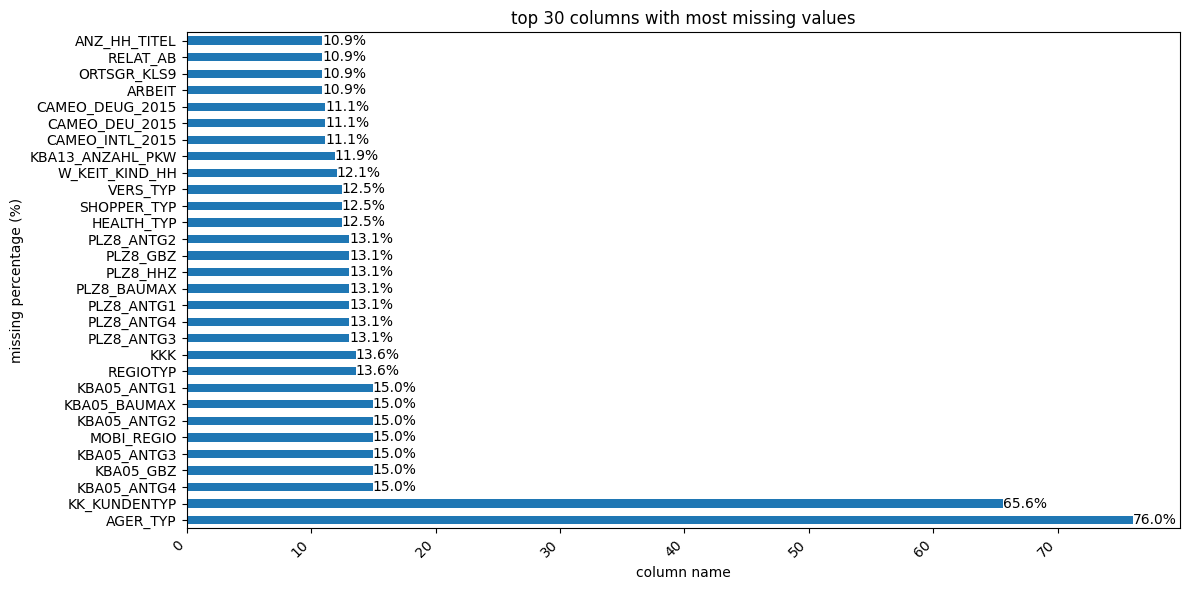

In [16]:
# plot top 30 columns with most missing values

top_missing = missing_pct.sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 6))
ax = top_missing.plot(kind='barh')

# Add values on bars
plt.bar_label(ax.containers[0], fmt='%.1f%%')


plt.xlabel('column name')
plt.ylabel('missing percentage (%)')
plt.title('top 30 columns with most missing values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)

# dropping columns with missing percentage > 16
drop_outliers = missing_pct[missing_pct>16].index
drop_outliers

Index(['AGER_TYP', 'KK_KUNDENTYP'], dtype='object')

In [18]:
# drop outliers from azdias dataframe
azdias.drop(columns=drop_outliers, axis='columns', inplace=True)

#### Discussion 1.1.2: Assess Missing Data in Each Column

There are a lot of missing values in the dataset. I chose to drop all columns with with missing percentage higher than 16%. 

columns
['AGER_TYP', 'KK_KUNDENTYP']
where dropped correspondingly

I also identified unknown values and replaced them with with NaN values.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

In [19]:
# How much data is missing in each row of the dataset?

# calculate missing values per row
missing_per_row = azdias.isnull().sum(axis=1)
missing_per_row.describe()

count    891221.000000
mean          5.214438
std          12.895292
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          47.000000
dtype: float64

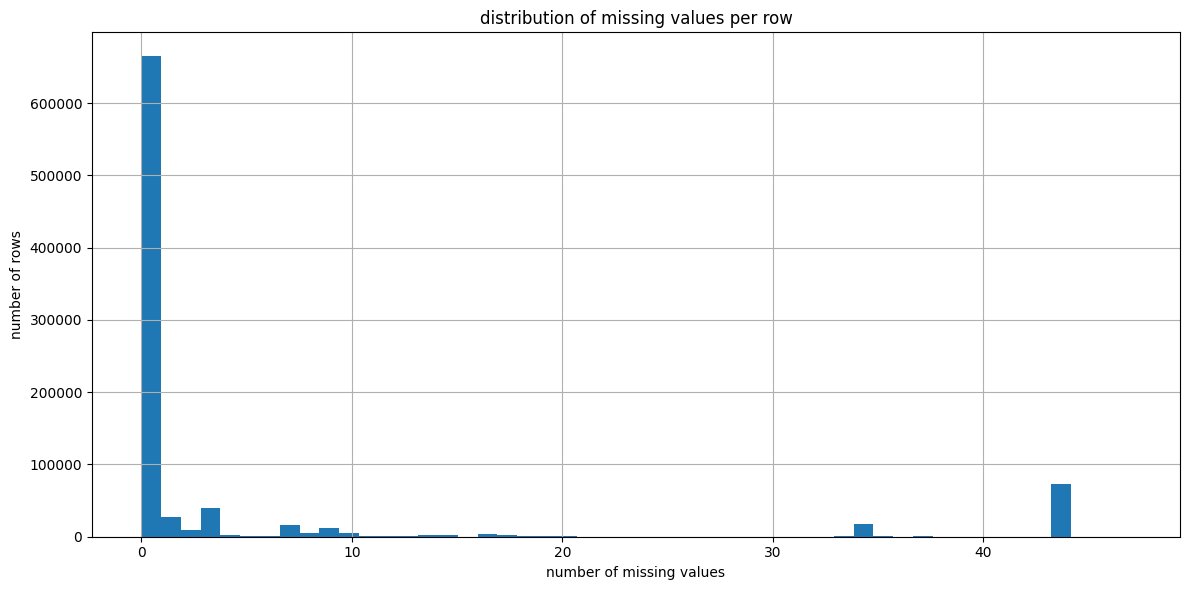

In [20]:
# visualize distribution of missing values per row

plt.figure(figsize=(12, 6))
missing_per_row.hist(bins=50)
plt.xlabel('number of missing values')
plt.ylabel('number of rows')
plt.title('distribution of missing values per row')
plt.tight_layout()
plt.show()

In [21]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

# threshold for missing values
threshold = 30

print(f"Threshold: {threshold} missing values")
print(f"Rows above threshold: {(missing_per_row > threshold).sum()}")
print(f"Rows below/equal threshold: {(missing_per_row <= threshold).sum()}")

Threshold: 30 missing values
Rows above threshold: 93150
Rows below/equal threshold: 798071


In [22]:
# split data into two subsets for selected threshold 

azdias_high_missing = azdias[missing_per_row > threshold].copy()
azdias_low_missing = azdias[missing_per_row <= threshold].copy()

print(f"\nHigh missing subset shape: {azdias_high_missing.shape}")
print(f"Low missing subset shape: {azdias_low_missing.shape}")


High missing subset shape: (93150, 83)
Low missing subset shape: (798071, 83)


In [23]:
# columns with very few missing values for comparison

missing_pct = (azdias.isnull().sum() / len(azdias)) * 100
low_missing_cols = missing_pct[missing_pct < 5].index.tolist()

print(f"Columns with <5% missing values: {len(low_missing_cols)}")
print(low_missing_cols[:10])  # Show first 10

Columns with <5% missing values: 39
['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZ_MINIMALIST', 'FINANZ_SPARER', 'FINANZ_VORSORGER', 'FINANZ_ANLEGER', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_HAUSBAUER', 'FINANZTYP']


In [24]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

def compare_distributions(col_name, df_high, df_low):
    """
    compare distributions of a column between high-missing and low-missing subsets
    
    Parameters:
    - col_name: column to compare
    - df_high: df with high missing values
    - df_low: df with low missing values   
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    
    # plot for low missing subset
    sns.countplot(x=col_name, data=df_low, ax=axes[1], color='steelblue')
    axes[0].set_title(f'{col_name} - low missing rows (n={len(df_low)})')
    axes[0].set_xlabel(col_name)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x')
    
    # plot for high missing subset
    sns.countplot(x=col_name, data=df_high, ax=axes[0], color='green')
    axes[1].set_title(f'{col_name} - high missing rows (n={len(df_high)})')
    axes[1].set_xlabel(col_name)
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x')
    
    plt.tight_layout()
    plt.show()  

Comparing columns: ['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZ_MINIMALIST', 'FINANZ_SPARER']


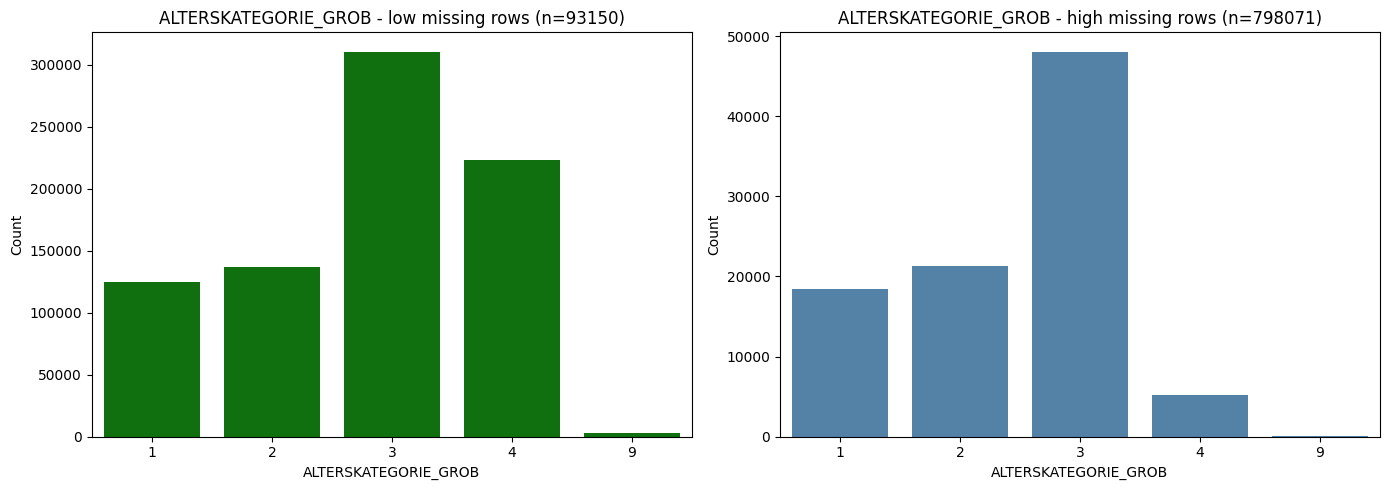

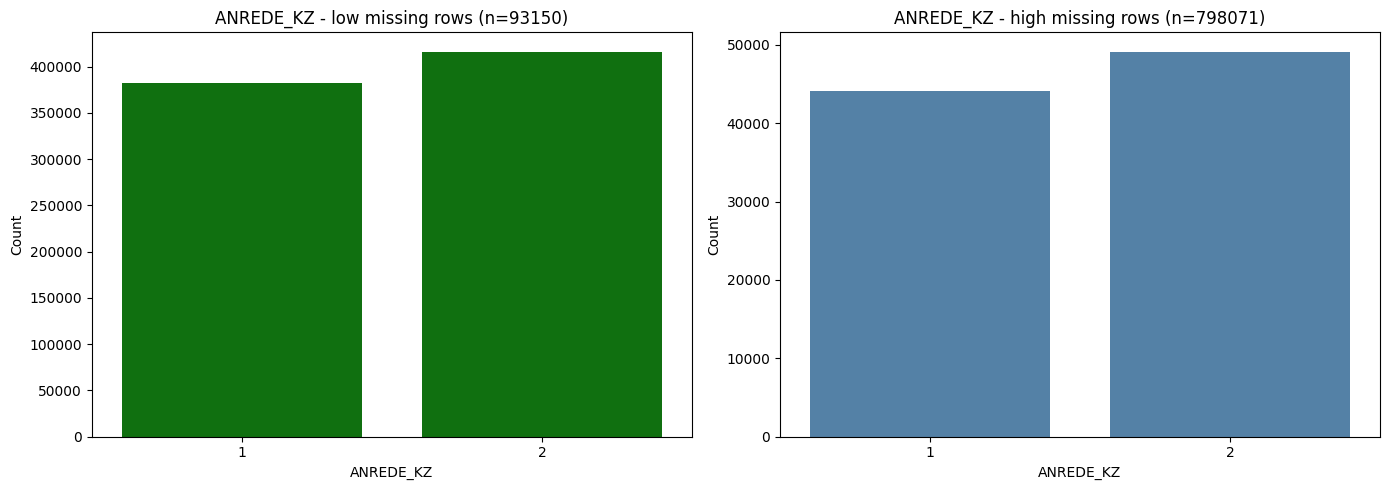

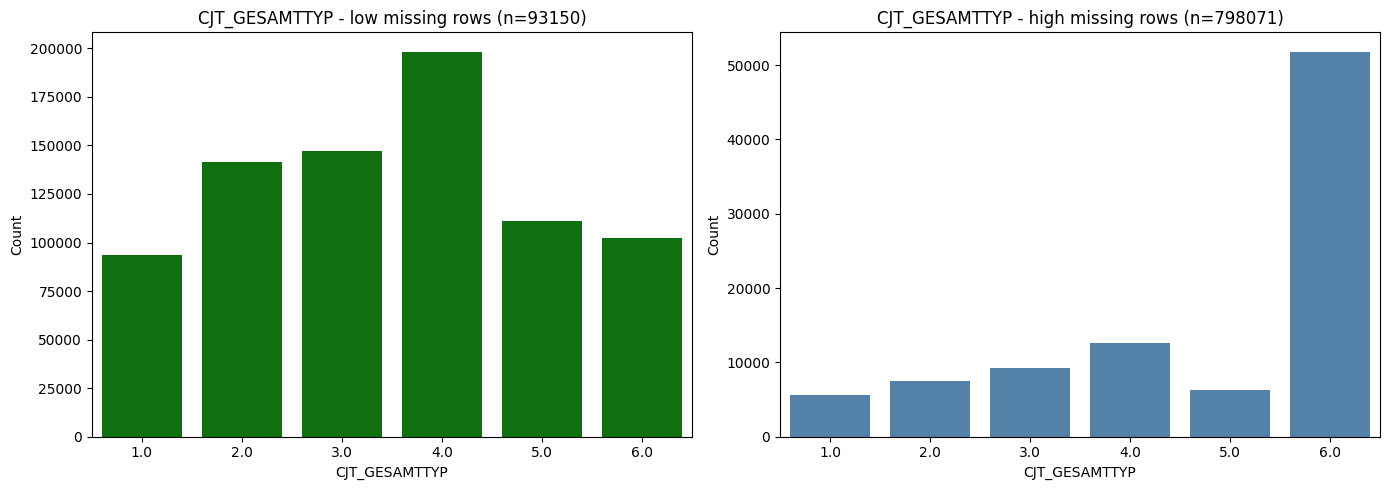

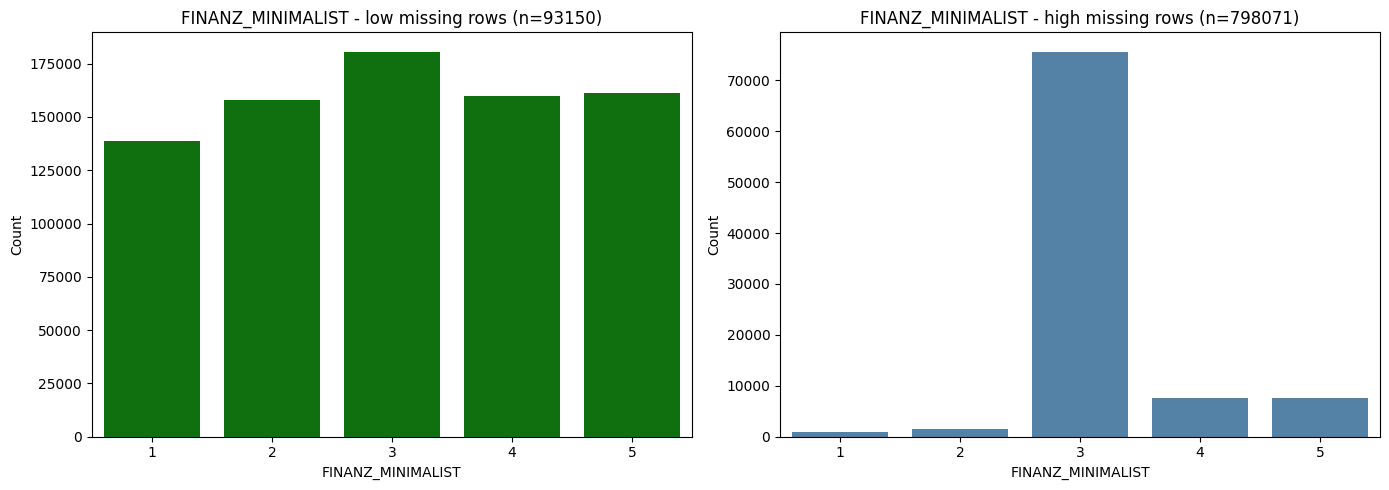

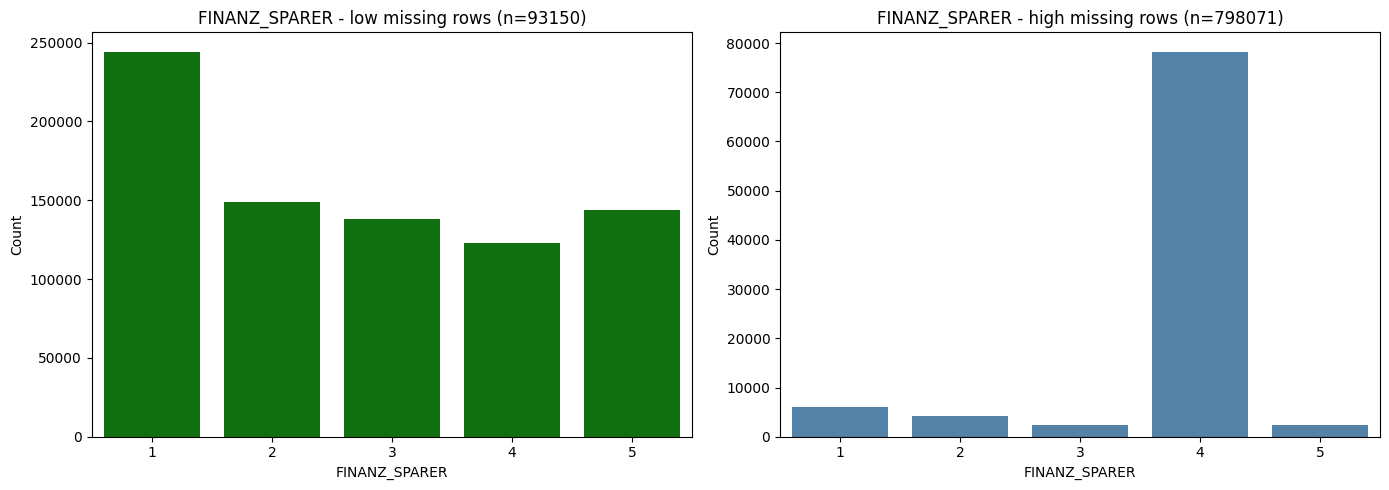

In [25]:
# selects 5 columns with low missing values for comparison
columns_to_compare = low_missing_cols[:5]  # Take first 5

print("Comparing columns:", columns_to_compare)

# runs comparison for each column
for col in columns_to_compare:
    compare_distributions(col, azdias_low_missing, azdias_high_missing)

#### Discussion 1.1.3: Assess Missing Data in Each Row

I have taken the threshold of 30 to seperate the rows above and below the chosen threshold, based on the basis of the histograms. While columns ALTERSKATEGORIE_GROB and ANREDE_KZ looks quite similar, FINANZ_MINIMALIST and FINANZ_SPARER have huge differences. 

From now on, i use the dataset with low missing values.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [26]:
# remove outlier columns from feat_info dataframe
feat_info = feat_info[feat_info.attribute.isin(azdias_low_missing.columns)]

In [27]:
feat_info.head(3)

,attribute,information_level,type,missing_or_unknown
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]


In [28]:
# How many features are there of each data type?
feat_info.type.value_counts()

type
ordinal        49
categorical    19
numeric         7
mixed           7
interval        1
Name: count, dtype: int64

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [29]:
# filter feat_info for categorical variables
categorical_info = feat_info[feat_info['type'] == 'categorical']
print(categorical_info)
print(f"\nTotal categorical variables: {len(categorical_info)}")

           attribute information_level         type missing_or_unknown
2          ANREDE_KZ            person  categorical             [-1,0]
3      CJT_GESAMTTYP            person  categorical                [0]
10         FINANZTYP            person  categorical               [-1]
12   GFK_URLAUBERTYP            person  categorical                 []
13  GREEN_AVANTGARDE            person  categorical                 []
17   LP_FAMILIE_FEIN            person  categorical                [0]
18   LP_FAMILIE_GROB            person  categorical                [0]
19    LP_STATUS_FEIN            person  categorical                [0]
20    LP_STATUS_GROB            person  categorical                [0]
21  NATIONALITAET_KZ            person  categorical             [-1,0]
38       SHOPPER_TYP            person  categorical               [-1]
39           SOHO_KZ            person  categorical               [-1]
40          TITEL_KZ            person  categorical             [-1,0]
41    

In [30]:
# list of categorical column names
categorical_cols = categorical_info['attribute'].to_list()

# check which categorical columns exist in azdias_low_missing
categorical_cols_in_data = [col for col in categorical_cols if col in azdias_low_missing.columns]

print(f"Categorical columns in dataset: {len(categorical_cols_in_data)}")
print(categorical_cols_in_data)

Categorical columns in dataset: 19
['ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'GREEN_AVANTGARDE', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'SOHO_KZ', 'TITEL_KZ', 'VERS_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'OST_WEST_KZ', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [31]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

binary_numeric = [] # binary with numeric values (keep as-is)
binary_non_numeric = [] # binary with non-numeric values (need encoding)
multi_level = [] # multi-level categoricals (drop or one-hot encode)

for col in categorical_cols_in_data:
    # get unique values excluding NaN
    unique_vals = azdias_low_missing[col].dropna().unique()
    n_unique = len(unique_vals)
    
    # check if values are numeric
    is_numeric = azdias_low_missing[col].dtype in ['int64', 'float64']
    
    print(f"\n--- {col} ---")
    print(f" unique values: {n_unique}")
    print(f"values: {unique_vals[:5]}") # show first 5
    print(f"data type: {azdias_low_missing[col].dtype}")
    
    # categorize the variable
    if n_unique == 2:
        if is_numeric:
            binary_numeric.append(col)
            print("category: binary with numeric values (keep as-is)")
        else:
            binary_non_numeric.append(col)
            print("category: binary with non-numeric values (need encoding)")
    elif n_unique > 2:
        multi_level.append(col)
        print("category: multi-level categoricals (drop or one-hot encode)")
    else:
        print("category: single-level categoricals (drop or one-hot encode)")


--- ANREDE_KZ ---
 unique values: 2
values: [2 1]
data type: int64
category: binary with numeric values (keep as-is)

--- CJT_GESAMTTYP ---
 unique values: 6
values: [5. 3. 2. 4. 1.]
data type: float64
category: multi-level categoricals (drop or one-hot encode)

--- FINANZTYP ---
 unique values: 6
values: [1 6 5 2 4]
data type: int64
category: multi-level categoricals (drop or one-hot encode)

--- GFK_URLAUBERTYP ---
 unique values: 12
values: [10.  1.  5. 12.  9.]
data type: float64
category: multi-level categoricals (drop or one-hot encode)

--- GREEN_AVANTGARDE ---
 unique values: 2
values: [0 1]
data type: int64
category: binary with numeric values (keep as-is)

--- LP_FAMILIE_FEIN ---
 unique values: 12
values: [ 5.  1.  0. 10.  2.]
data type: float64
category: multi-level categoricals (drop or one-hot encode)

--- LP_FAMILIE_GROB ---
 unique values: 6
values: [3. 1. 0. 5. 2.]
data type: float64
category: multi-level categoricals (drop or one-hot encode)

--- LP_STATUS_FEIN ---
 

In [32]:
# summary of categorical variables
print(f"\nbinary numeric (keep as-is): {len(binary_numeric)}")
print(binary_numeric)

print(f"\nbinary non-numeric (need encoding): {len(binary_non_numeric)}")
print(binary_non_numeric)

print(f"\nmulti-level (drop or one-hot encode): {len(multi_level)}")
print(multi_level)


binary numeric (keep as-is): 4
['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'VERS_TYP']

binary non-numeric (need encoding): 1
['OST_WEST_KZ']

multi-level (drop or one-hot encode): 14
['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'TITEL_KZ', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [33]:
# re-encode binary non-numeric values

for col in binary_non_numeric:
    print(f"\nencoding: {col}")
    print(f"original values: {azdias_low_missing[col].unique()}")
        
    # create mapping: first value -> 0, second value -> 1
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    print(f"mapping: {mapping}")
    
    # apply encoding
    azdias_low_missing[col] = azdias_low_missing[col].map(mapping)


encoding: OST_WEST_KZ
original values: ['W' 'O']
mapping: {'8A': 0, '4C': 1}


In [34]:
# Re-encode categorical variable(s) to be kept in the analysis.

# drop multi-level categorical columns

print(f"\ndropping {len(multi_level)} multi-level categorical columns:")
print(multi_level)

# shape before dropping
shape_before = azdias_low_missing.shape

# drop multi-level categorical columns
azdias_clean = azdias_low_missing.drop(columns=multi_level)

# shape after dropping
shape_after = azdias_clean.shape

print(f"\nShape before: {shape_before}")
print(f"Shape after: {shape_after}")
print(f"Columns removed: {shape_before[1] - shape_after[1]}")


dropping 14 multi-level categorical columns:
['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'TITEL_KZ', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']

Shape before: (798071, 83)
Shape after: (798071, 69)
Columns removed: 14


In [35]:
# re-check remaining categorical columns
remaining_categorical = [col for col in categorical_cols_in_data if col in azdias_clean.columns]
remaining_categorical

['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'VERS_TYP', 'OST_WEST_KZ']

#### Discussion 1.2.1: Re-Encode Categorical Features

There are a lot of columns with multi-level-categorical variables. I chose to drop them. I also encoded OST_WEST_KZ and keep it at this moment. And ofc i kept the "keep as-is" numeric columns.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

### 1.18. PRAEGENDE_JUGENDJAHRE
Dominating movement of person's youth (avantgarde vs. mainstream; east vs. west)
- -1: unknown
-  0: unknown
-  1: 40s - war years (Mainstream, E+W)
-  2: 40s - reconstruction years (Avantgarde, E+W)
-  3: 50s - economic miracle (Mainstream, E+W)
-  4: 50s - milk bar / Individualisation (Avantgarde, E+W)
-  5: 60s - economic miracle (Mainstream, E+W)
-  6: 60s - generation 68 / student protestors (Avantgarde, W)
-  7: 60s - opponents to the building of the Wall (Avantgarde, E)
-  8: 70s - family orientation (Mainstream, E+W)
-  9: 70s - peace movement (Avantgarde, E+W)
- 10: 80s - Generation Golf (Mainstream, W)
- 11: 80s - ecological awareness (Avantgarde, W)
- 12: 80s - FDJ / communist party youth organisation (Mainstream, E)
- 13: 80s - Swords into ploughshares (Avantgarde, E)
- 14: 90s - digital media kids (Mainstream, E+W)
- 15: 90s - ecological awareness (Avantgarde, E+W)

In [36]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.

# show first rows of PRAEGENDE_JUGENDJAHRE
azdias_clean.PRAEGENDE_JUGENDJAHRE.head()

1    14
2    15
3     8
4     8
5     3
Name: PRAEGENDE_JUGENDJAHRE, dtype: int64

In [37]:
# replace unknown values (-1, 0) with NaN
azdias_clean['PRAEGENDE_JUGENDJAHRE'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].replace([-1, 0], np.nan)

In [38]:
# mapping for DECADE (internal variable)
decade_mapping = {
    1: 40, 2: 40,                     # 1940s
    3: 50, 4: 50,                     # 1950s
    5: 60, 6: 60, 7:60,               # 1960s
    8: 80, 9: 70,                     # 1970s
    10: 80, 11: 80, 12: 80, 13: 80,   # 1980s
    14: 90, 15: 90                    # 1990s
}

# mapping for MOVEMENT (binary variable)
# 0 = mainstream 1 = avantgarde

movement_mapping = {
    1: 0,   # 40s - Mainstream
    2: 1,   # 40s - Avantgarde
    3: 0,   # 50s - Mainstream
    4: 1,   # 50s - Avantgarde
    5: 0,   # 60s - Mainstream
    6: 1,   # 60s - Avantgarde
    7: 1,   # 60s - Avantgarde
    8: 0,   # 70s - Mainstream
    9: 1,   # 70s - Avantgarde
    10: 0,  # 80s - Mainstream
    11: 1,  # 80s - Avantgarde
    12: 0,  # 80s - Mainstream
    13: 1,  # 80s - Avantgarde
    14: 0,  # 90s - Mainstream
    15: 1   # 90s - Avantgarde   
}

In [39]:
# apply created mappings to create new features
azdias_clean['PRAEGENDE_JUGENDJAHRE_DECADE'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_mapping)
azdias_clean['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_mapping)

In [40]:
# verify new features
print(azdias_clean['PRAEGENDE_JUGENDJAHRE_DECADE'].value_counts().sort_index())
print(azdias_clean['PRAEGENDE_JUGENDJAHRE_MOVEMENT'].value_counts().sort_index())

PRAEGENDE_JUGENDJAHRE_DECADE
40.0     28157
50.0     74296
60.0    114354
70.0     33570
80.0    293400
90.0    225532
Name: count, dtype: int64
PRAEGENDE_JUGENDJAHRE_MOVEMENT
0.0    594084
1.0    175225
Name: count, dtype: int64


### 4.3. CAMEO_INTL_2015
German CAMEO: Wealth / Life Stage Typology, mapped to international code
- -1: unknown
- 11: Wealthy Households - Pre-Family Couples & Singles
- 12: Wealthy Households - Young Couples With Children
- 13: Wealthy Households - Families With School Age Children
- 14: Wealthy Households - Older Families &  Mature Couples
- 15: Wealthy Households - Elders In Retirement
- 21: Prosperous Households - Pre-Family Couples & Singles
- 22: Prosperous Households - Young Couples With Children
- 23: Prosperous Households - Families With School Age Children
- 24: Prosperous Households - Older Families & Mature Couples
- 25: Prosperous Households - Elders In Retirement
- 31: Comfortable Households - Pre-Family Couples & Singles
- 32: Comfortable Households - Young Couples With Children
- 33: Comfortable Households - Families With School Age Children
- 34: Comfortable Households - Older Families & Mature Couples
- 35: Comfortable Households - Elders In Retirement
- 41: Less Affluent Households - Pre-Family Couples & Singles
- 42: Less Affluent Households - Young Couples With Children
- 43: Less Affluent Households - Families With School Age Children
- 44: Less Affluent Households - Older Families & Mature Couples
- 45: Less Affluent Households - Elders In Retirement
- 51: Poorer Households - Pre-Family Couples & Singles
- 52: Poorer Households - Young Couples With Children
- 53: Poorer Households - Families With School Age Children
- 54: Poorer Households - Older Families & Mature Couples
- 55: Poorer Households - Elders In Retirement
- XX: unknown

In [41]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

# show first rows of 
azdias_clean.CAMEO_INTL_2015.head()

1    51
2    24
3    12
4    43
5    54
Name: CAMEO_INTL_2015, dtype: object

In [42]:
# replace unknown values of CAMEO_INTL_2015 with NaN
azdias_clean['CAMEO_INTL_2015'] = azdias_clean['CAMEO_INTL_2015'].replace([-1, 'XX', -1.0], np.nan)

In [43]:
# convert to numeric
cameo_numeric = pd.to_numeric(azdias_clean['CAMEO_INTL_2015'], errors='coerce')

# extract ten digit (wealth): integer divison by 10
# 11 // 10 = 1, 25 // 10 = 2, etc
azdias_clean['CAMEO_WEALTH'] = cameo_numeric // 10

In [44]:
# show first rows of new column in comparison with old
azdias_clean[['CAMEO_WEALTH', 'CAMEO_INTL_2015']].head()

,CAMEO_WEALTH,CAMEO_INTL_2015
1,5.0,51
2,2.0,24
3,1.0,12
4,4.0,43
5,5.0,54


In [45]:
# extract ones digit (life stage): modulo 10
# 11 % 10 = 1, 25 % 10 = 5, etc.
azdias_clean['CAMEO_LIFESTAGE'] = cameo_numeric % 10

In [46]:
# show first rows of new column in comparison with old
azdias_clean[['CAMEO_LIFESTAGE', 'CAMEO_INTL_2015']].head()

,CAMEO_LIFESTAGE,CAMEO_INTL_2015
1,1.0,51
2,4.0,24
3,2.0,12
4,3.0,43
5,4.0,54


#### Discussion 1.2.2: Engineer Mixed-Type Features

I did mapping for the column PRAEGENDE_JUGENDJAHRE and also replaced unkown values with NaN. I also created new columns for the mapping PRAEGENDE_JUGENDJAHRE_DECADE and PRAEGENDE_JUGENDJAHRE_MOVEMENT. 

For the column CAMEO_INTL_2015 i converted the column to numerics, so that i can do calculations and map the columns to health and life stage, which resulted in new columns CAMEO_WEALTH and  CAMEO_LIFESTAGE.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [47]:
# remove unused columns CAMEO_INTL_2015 and PRAEGENDE_JUGENDJAHRE
azdias_clean = azdias_clean.drop(columns=['CAMEO_INTL_2015'])
azdias_clean = azdias_clean.drop(columns=['PRAEGENDE_JUGENDJAHRE'])

### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [48]:
def clean_data(df, features):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    azdias = df
    feat_info = features
    
    missing_per_row = azdias.isnull().sum(axis=1)
    categorical_info = feat_info[feat_info['type'] == 'categorical']
    
    # placeholders for missing data
    unknown_values = [-1, -999, 999, 9999, 'unknown', 'Unknown', 'UNKNOWN', 
                      'NA', 'N/A', 'n/a', 'null', 'NULL', '', ' ', '?', 'X', 'XX', 'XXX']
                
    # replace unknown values with NaN
    azdias.replace(unknown_values, np.nan, inplace=True)
    
    # percentage of missing values per column
   # missing_pct = (azdias.isnull().sum() / len(azdias)) * 100
    
    # dropping columns with missing percentage > 16
   # drop_outliers = missing_pct[missing_pct>16].index

    # drop outliers from azdias dataframe
   # azdias.drop(columns=drop_outliers, axis='columns', inplace=True)
    
    # threshold for missing values
    threshold = 30
    
    # split data into subset for selected threshold 
  #  azdias_low_missing = azdias[missing_per_row <= threshold].copy()
    
    azdias_low_missing = azdias
    
    # remove outlier columns from feat_info dataframe
    low_missing_cols = missing_pct[missing_pct < 5].index.tolist()
    feat_info = feat_info[feat_info.attribute.isin(azdias_low_missing.columns)]
    
    # list of categorical column names
    categorical_cols = categorical_info['attribute'].to_list()
    
    # check which categorical columns exist in azdias_low_missing
    categorical_cols_in_data = [col for col in categorical_cols if col in azdias_low_missing.columns]
    
    # Assess categorical variables: which are binary, which are multi-level, and
    # which one needs to be re-encoded?

    binary_numeric = [] # binary with numeric values (keep as-is)
    binary_non_numeric = [] # binary with non-numeric values (need encoding)
    multi_level = [] # multi-level categoricals (drop or one-hot encode)
    
    for col in categorical_cols_in_data:
        # get unique values excluding NaN
        unique_vals = azdias_low_missing[col].dropna().unique()
        n_unique = len(unique_vals)

        # check if values are numeric
        is_numeric = azdias_low_missing[col].dtype in ['int64', 'float64']

        # categorize the variable
        if n_unique == 2:
            if is_numeric:
                binary_numeric.append(col)
            else:
                binary_non_numeric.append(col)
        elif n_unique > 2:
            multi_level.append(col)
            
    # re-encode binary non-numeric values

    for col in binary_non_numeric:
        # create mapping: first value -> 0, second value -> 1
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        
        # apply encoding
        azdias_low_missing[col] = azdias_low_missing[col].map(mapping)
        
    # drop multi-level categorical columns
   # azdias_clean = azdias_low_missing.drop(columns=multi_level)
    
    azdias_clean = azdias_low_missing
    
    # replace unknown values (-1, 0) with NaN
    azdias_clean['PRAEGENDE_JUGENDJAHRE'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].replace([-1, 0], np.nan)
    
    # mapping for DECADE (internal variable)
    decade_mapping = {
        1: 40, 2: 40,                     # 1940s
        3: 50, 4: 50,                     # 1950s
        5: 60, 6: 60, 7:60,               # 1960s
        8: 80, 9: 70,                     # 1970s
        10: 80, 11: 80, 12: 80, 13: 80,   # 1980s
        14: 90, 15: 90                    # 1990s
    }

    # mapping for MOVEMENT (binary variable)
    # 0 = mainstream 1 = avantgarde

    movement_mapping = {
        1: 0,   # 40s - Mainstream
        2: 1,   # 40s - Avantgarde
        3: 0,   # 50s - Mainstream
        4: 1,   # 50s - Avantgarde
        5: 0,   # 60s - Mainstream
        6: 1,   # 60s - Avantgarde
        7: 1,   # 60s - Avantgarde
        8: 0,   # 70s - Mainstream
        9: 1,   # 70s - Avantgarde
        10: 0,  # 80s - Mainstream
        11: 1,  # 80s - Avantgarde
        12: 0,  # 80s - Mainstream
        13: 1,  # 80s - Avantgarde
        14: 0,  # 90s - Mainstream
        15: 1   # 90s - Avantgarde   
    }
    
    # apply created mappings to create new features
    azdias_clean['PRAEGENDE_JUGENDJAHRE_DECADE'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_mapping)
    azdias_clean['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = azdias_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_mapping)
    
    # replace unknown values of CAMEO_INTL_2015 with NaN
    if 'CAMEO_INTL_2015' in azdias_clean.columns:
        azdias_clean['CAMEO_INTL_2015'] = azdias_clean['CAMEO_INTL_2015'].replace([-1, 'XX', -1.0], np.nan)
    
    # convert to numeric
        cameo_numeric = pd.to_numeric(azdias_clean['CAMEO_INTL_2015'], errors='coerce')

        # extract ten digit (wealth): integer divison by 10
        # 11 // 10 = 1, 25 // 10 = 2, etc
        azdias_clean['CAMEO_WEALTH'] = cameo_numeric // 10

        # extract ones digit (life stage): modulo 10
        # 11 % 10 = 1, 25 % 10 = 5, etc.
        azdias_clean['CAMEO_LIFESTAGE'] = cameo_numeric % 10

        # remove unused columns CAMEO_INTL_2015 and PRAEGENDE_JUGENDJAHRE
        azdias_clean = azdias_clean.drop(columns=['CAMEO_INTL_2015'])
    else:
        print("column 'CAMEO_INTL_2015' doesn't exist in dataframe")
        
    azdias_clean = azdias_clean.drop(columns=['PRAEGENDE_JUGENDJAHRE'])
    
    if 'OST_WEST_KZ' in azdias_clean.columns:
        if azdias_clean['OST_WEST_KZ'].notna().sum() == 0:
            azdias_clean = azdias_clean.drop(columns=['OST_WEST_KZ'])
    else:
        print("column 'OST_WEST_KZ' doesn't exist in dataframe")
    
    return azdias_clean

In [49]:
# test function
azdias_test = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')
feat_info_test = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')
test_df = clean_data(azdias_test, feat_info_test)

In [50]:
# show first rows of test dataframe
test_df.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
0,NaN,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,NaN,15.0,4.0,2.0,2.0,1.0,1.0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3.0,21.0,6.0,5.0,3.0,2.0,1.0,1,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,0.0,2.0,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,4.0,8,8A,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0,90.0,0.0,5.0,1.0
2,NaN,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3.0,3.0,1.0,1.0,1.0,3.0,2.0,1,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,0.0,1.0,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,2.0,4,4C,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0,90.0,1.0,2.0,4.0
3,2.0,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2.0,0.0,0.0,0.0,0.0,9.0,4.0,1,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,0.0,1.0,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,7.0,2,2A,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0,80.0,0.0,1.0,2.0
4,NaN,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3.0,32.0,10.0,10.0,5.0,3.0,2.0,1,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,0.0,2.0,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,3.0,6,6B,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0,80.0,0.0,4.0,3.0


## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [51]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

#check for missing values
azdias_clean.isnull().sum().sum()

1525479

In [52]:
# OST_WEST_KZ made problems while performing SimpleImputer 
# if all values are NaN, drop the column
if azdias_clean['OST_WEST_KZ'].notna().sum() == 0:
    print("\nall values are NaN - dropping column...")
    azdias_clean = azdias_clean.drop(columns=['OST_WEST_KZ'])
    print("dropped OST_WEST_KZ")


all values are NaN - dropping column...
dropped OST_WEST_KZ


In [53]:
# handle missing values

# store column and index
column_names = azdias_clean.columns
index_values = azdias_clean.index

# create and fit imputer
imputer = SimpleImputer(strategy='most_frequent')
azdias_clean = pd.DataFrame(
    imputer.fit_transform(azdias_clean),
    columns = column_names,
    index = index_values
)

In [54]:
# check whether there are still missing values
azdias_clean.isnull().sum().sum()

0

In [55]:
# apply feature scaling to the general population demographics data
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_clean)

# convert to dataframe for easier inspection
azdias_scaled_df = pd.DataFrame(
    azdias_scaled,
    columns = column_names,
    index = index_values)

In [56]:
# print sample of scaled values
print(azdias_scaled_df.iloc[:5, :5])

   ALTERSKATEGORIE_GROB  ANREDE_KZ  FINANZ_MINIMALIST  FINANZ_SPARER  \
1             -1.681272   0.957908          -1.494591       1.537914   
2              0.169121   0.957908          -1.494591       0.864555   
3              1.094317   0.957908           0.683149      -0.482164   
4              0.169121  -1.043942           0.683149       0.191195   
5             -1.681272   0.957908          -0.042764      -1.155524   

   FINANZ_VORSORGER  
1         -1.040682  
2         -1.766968  
3          1.138177  
4          0.411891  
5          1.138177  


### Discussion 2.1: Apply Feature Scaling

First of all i dropped the OST_WEST_KZ column, as it created problems with the SimpleImputer. After that i filled the missing values with SimpleImputer and chose the most_frequent strategy, as we have categorical columns in our dataset.

Also each feature has been scaled to mean 0 and standard deviation 1, using StandardScaler instance.
It is important to have a uniform scale, which can improve the convergence of algorithms like gradient descent.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [57]:
# apply PCA to the data.
pca_full = PCA()
pca_full.fit(azdias_scaled_df)

PCA()

In [58]:
# Investigate the variance accounted for by each principal component.
variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# display top components
print("\nVariance explained by top 20 components:")
print("-"*50)
print(f"{'Component':<12} {'Individual %':<15} {'Cumulative %':<15}")
print("-"*50)

for i in range(20):
    print(f"PC {i+1:<9} {variance_ratio[i]*100:>12.2f}%    {cumulative_variance[i]*100:>12.2f}%")


Variance explained by top 20 components:
--------------------------------------------------
Component    Individual %    Cumulative %   
--------------------------------------------------
PC 1                16.83%           16.83%
PC 2                12.33%           29.15%
PC 3                 8.70%           37.85%
PC 4                 5.38%           43.24%
PC 5                 3.88%           47.12%
PC 6                 3.25%           50.37%
PC 7                 2.98%           53.35%
PC 8                 2.46%           55.80%
PC 9                 2.39%           58.20%
PC 10                2.24%           60.44%
PC 11                2.00%           62.44%
PC 12                1.84%           64.28%
PC 13                1.84%           66.11%
PC 14                1.75%           67.86%
PC 15                1.64%           69.51%
PC 16                1.55%           71.06%
PC 17                1.43%           72.48%
PC 18                1.34%           73.82%
PC 19              

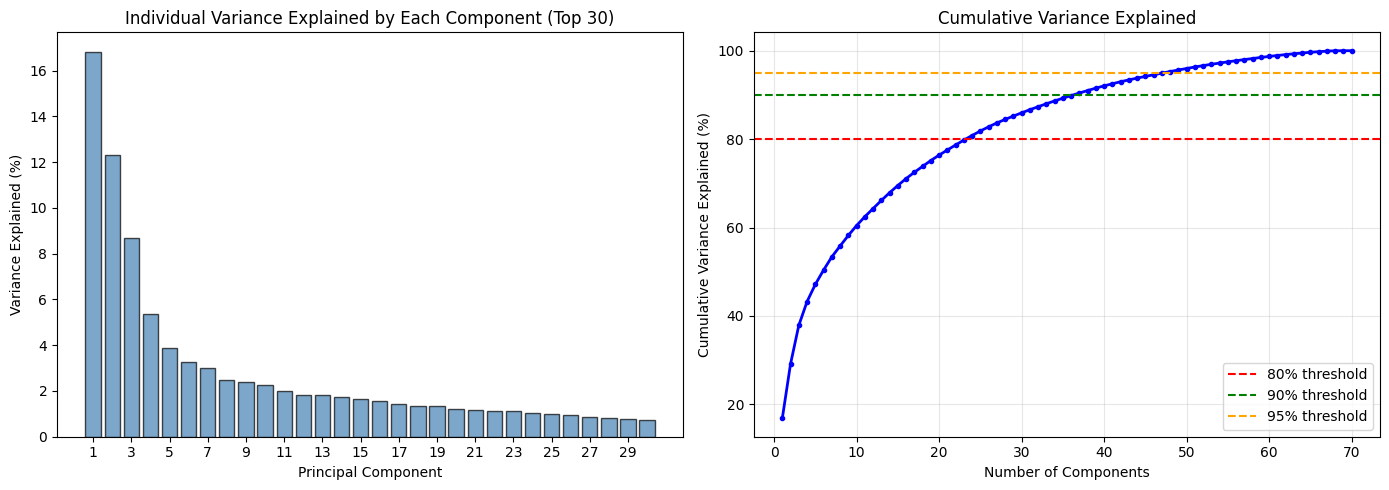

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

# individual variance (bar chart - top 30)
ax1 = axes[0]
components_to_show = 30
ax1.bar(range(1, components_to_show + 1), variance_ratio[:components_to_show] * 100, 
        color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Individual Variance Explained by Each Component (Top 30)')
ax1.set_xticks(range(1, components_to_show + 1, 2))

# Cumulative variance (line chart - all components)
ax2 = axes[1]
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
         'b-', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=80, color='r', linestyle='--', label='80% threshold')
ax2.axhline(y=90, color='g', linestyle='--', label='90% threshold')
ax2.axhline(y=95, color='orange', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

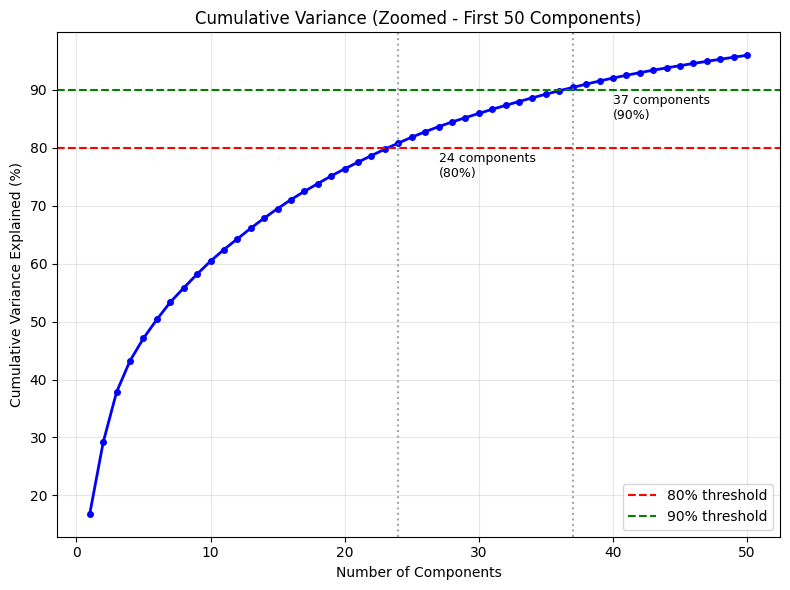

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

zoom_n = min(50, len(cumulative_variance))
ax.plot(range(1, zoom_n + 1), cumulative_variance[:zoom_n] * 100, 
        'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=80, color='r', linestyle='--', label='80% threshold')
ax.axhline(y=90, color='g', linestyle='--', label='90% threshold')

# mark thresholds with vertical lines and annotations
for threshold in [0.80, 0.90]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    ax.axvline(x=n_components, color='gray', linestyle=':', alpha=0.7)
    ax.annotate(f'{n_components} components\n({threshold*100:.0f}%)', 
                xy=(n_components, threshold*100), 
                xytext=(n_components + 3, threshold*100 - 5),
                fontsize=9)

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('Cumulative Variance (Zoomed - First 50 Components)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# Re-apply PCA to the data while selecting for number of components to retain.

# find components for ~80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

# re-fit PCA with selected number of components
pca_final = PCA(n_components_80)
azdias_pca = pca_final.fit_transform(azdias_scaled_df)

In [62]:
pca_final.components_.shape

(24, 70)

In [63]:
azdias_pca.shape

(798071, 24)

In [64]:
azdias_scaled_df.shape

(798071, 70)

### Discussion 2.2: Perform Dimensionality Reduction

Before i had 70 components. With PCA 24 components were able to achive 80% of cumulative variance. Therefor i go with 24 components. 

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [65]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

def map_pc_weights(pca, feature_names, component_num):
    """
    maps principal component weights to feature names and display sorted list
    
    Parameters:
    -----------
    pca : fitted PCA object
        The PCA object after fitting
    feature_names : list or array
        List of feature names corresponding to the original data columns
    component_num : int
        which principal component to analyze (PC1=1, PC2=2, etc.)
    
    Returns:
    --------
    pd.DataFrame : DataFrame with features and weights, sorted by weight descending
    """
    
    # get weights for selected component
    weights = pca.components_[component_num]
    
    # create dataframe with features names and weights
    weight_df = pd.DataFrame({
        'Feature': feature_names,
        'Weight': weights
    })
    
    # sort by weight
    weight_df_sorted = weight_df.sort_values('Weight', ascending=False)
    
    return weight_df_sorted

In [66]:
# get feature names
feature_names = azdias_scaled_df.columns.tolist()

# analyze PC1
pc1_weights = map_pc_weights(pca_final, feature_names, component_num = 1)
pc1_weights

,Feature,Weight
0,ALTERSKATEGORIE_GROB,0.259469
4,FINANZ_VORSORGER,0.247892
20,SEMIO_ERL,0.236950
19,SEMIO_LUST,0.191224
13,RETOURTYP_BK_S,0.164764
34,W_KEIT_KIND_HH,0.120459
23,SEMIO_KRIT,0.111656
25,SEMIO_KAEM,0.102147
2,FINANZ_MINIMALIST,0.099634
7,FINANZ_HAUSBAUER,0.091788


In [67]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
pc2_weights = map_pc_weights(pca_final, feature_names, component_num = 2)
pc2_weights

,Feature,Weight
18,SEMIO_VERT,0.346229
14,SEMIO_SOZ,0.262348
15,SEMIO_FAM,0.249568
21,SEMIO_KULT,0.236151
2,FINANZ_MINIMALIST,0.160704
13,RETOURTYP_BK_S,0.105028
4,FINANZ_VORSORGER,0.100023
34,W_KEIT_KIND_HH,0.092374
0,ALTERSKATEGORIE_GROB,0.071149
16,SEMIO_REL,0.070474


In [68]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
pc3_weights = map_pc_weights(pca_final, feature_names, component_num = 3)
pc3_weights

,Feature,Weight
67,PRAEGENDE_JUGENDJAHRE_MOVEMENT,0.329667
9,GREEN_AVANTGARDE,0.329667
11,LP_LEBENSPHASE_FEIN,0.253578
12,LP_LEBENSPHASE_GROB,0.251614
64,ORTSGR_KLS9,0.244792
48,EWDICHTE,0.239575
31,ANZ_PERSONEN,0.236005
53,ONLINE_AFFINITAET,0.201325
30,ALTER_HH,0.148115
65,RELAT_AB,0.110294


### Discussion 2.3: Interpret Principal Components


PC1:
What is interesting, that the weight of FINANZ_VORSORGER is quite high and the weight of FINANZ_SPARER quite low, because normaly you would think, that people that prepare themselfes financially would also the ones who are money-savers. 

PC2:
You could interpret that SEMIO_VERT (dreamful people) don't have much correlation with SEMIO_DOM (dominant) minded people. 

PC3:
You could interpret that GREEN_AVANTGARDE people are not the type of people that are investors (FINANZ_ANLEGER)

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

cluster: 6, inertia: 30,057,928, avg distance: 37.6632
cluster: 7, inertia: 28,933,253, avg distance: 36.2540
cluster: 8, inertia: 28,095,017, avg distance: 35.2037
cluster: 9, inertia: 27,425,110, avg distance: 34.3642
cluster: 10, inertia: 26,844,834, avg distance: 33.6372
cluster: 11, inertia: 26,343,829, avg distance: 33.0094
cluster: 12, inertia: 25,663,351, avg distance: 32.1567
cluster: 13, inertia: 25,239,652, avg distance: 31.6258
cluster: 14, inertia: 24,935,095, avg distance: 31.2442
cluster: 15, inertia: 24,570,799, avg distance: 30.7877
cluster: 16, inertia: 24,178,972, avg distance: 30.2968
cluster: 17, inertia: 23,887,843, avg distance: 29.9320
cluster: 18, inertia: 23,436,898, avg distance: 29.3669
cluster: 19, inertia: 23,373,343, avg distance: 29.2873
cluster: 20, inertia: 22,762,407, avg distance: 28.5218
cluster: 21, inertia: 22,556,996, avg distance: 28.2644
cluster: 22, inertia: 22,186,586, avg distance: 27.8003
cluster: 23, inertia: 22,152,299, avg distance: 27.7

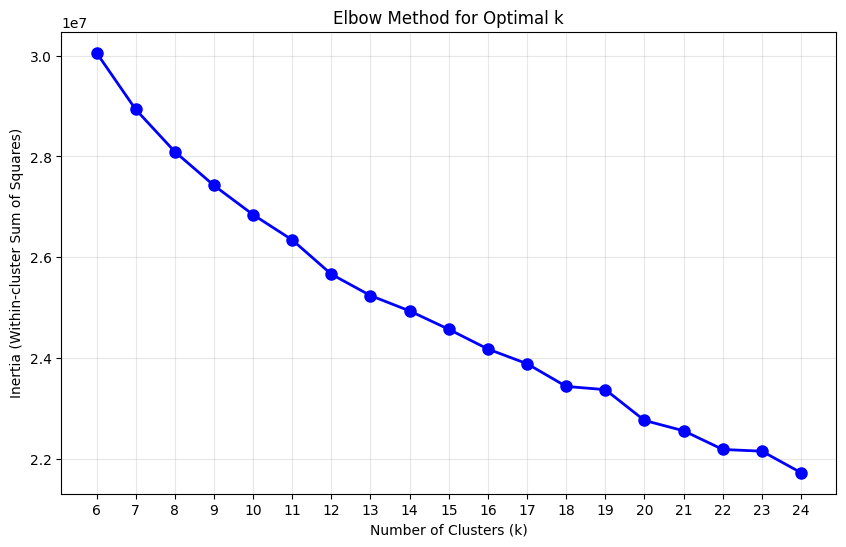

In [69]:
# test different cluster counts
cluster_range = range(6, 25)

# store results
cluster_counts = []
inertias = [] # within-cluster sum of squares
scores = [] # negative intertia

    # run k-means clustering on the data and...
    
for k in cluster_range:
    
    # initliaze and fit kmeans
    kmeans = KMeans(n_clusters = k,
                   random_state=42,
                   n_init=10,
                   max_iter=300)
    
    kmeans.fit(azdias_pca)
    
    # store results
    cluster_counts.append(k)
    
    # inertia: sum of squared distances to closes cluster center
    inertias.append(kmeans.inertia_)
    
    # score: negative inertia
    score = kmeans.score(azdias_pca)
    scores.append(score)
    
    # calculate average within-cluster distance
    avg_distance = kmeans.inertia_ / azdias_pca.shape[0]
    
    # compute the average within-cluster distances.
    
    print(f"cluster: {k}, inertia: {kmeans.inertia_:,.0f}, avg distance: {avg_distance:.4f}")

# plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(list(cluster_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.xticks(list(cluster_range))
plt.show()

In [70]:
# cluster predictions for the general population demographics data.

# calculates average within-cluster distances
avg_distances = [inertia / azdias_pca.shape[0] for inertia in inertias]

# create results DataFrame
results_df = pd.DataFrame({
    'Clusters': cluster_counts,
    'Inertia': inertias,
    'Avg_Distance': avg_distances,
    'Score': scores
})

# calculate percentage decrease in inertia
results_df['Inertia_Decrease'] = results_df['Inertia'].pct_change() * -100
results_df['Inertia_Decrease'] = results_df['Inertia_Decrease'].fillna(0)

print("\nResults Summary:")
print(results_df.to_string(index=False))

# find elbow point using the "knee" method
# calculates second derivative to find point of maximum curvature
inertia_array = np.array(inertias)
first_derivative = np.diff(inertia_array)
second_derivative = np.diff(first_derivative)

# elbow is approximately where the second derivative is maximum
elbow_idx = np.argmax(second_derivative) + 2  # +2 because of two diff operations
suggested_k = cluster_counts[elbow_idx]


Results Summary:
 Clusters      Inertia  Avg_Distance         Score  Inertia_Decrease
        6 3.005793e+07     37.663226 -3.005793e+07          0.000000
        7 2.893325e+07     36.253984 -2.893325e+07          3.741692
        8 2.809502e+07     35.203656 -2.809502e+07          2.897138
        9 2.742511e+07     34.364249 -2.742511e+07          2.384432
       10 2.684483e+07     33.637150 -2.684483e+07          2.115858
       11 2.634383e+07     33.009380 -2.634383e+07          1.866301
       12 2.566335e+07     32.156726 -2.566335e+07          2.583064
       13 2.523965e+07     31.625823 -2.523965e+07          1.650985
       14 2.493509e+07     31.244206 -2.493509e+07          1.206664
       15 2.457080e+07     30.787735 -2.457080e+07          1.460977
       16 2.417897e+07     30.296769 -2.417897e+07          1.594682
       17 2.388784e+07     29.931977 -2.388784e+07          1.204061
       18 2.343690e+07     29.366934 -2.343690e+07          1.887758
       19 2.3373

In [71]:
print(f"number of clusters (based on elbow): {suggested_k}")

number of clusters (based on elbow): 21


In [72]:
# select and re-fit with calculated k
n_clusters_selected = suggested_k  

kmeans_final = KMeans(n_clusters=n_clusters_selected, random_state=42, n_init=10)
azdias_clusters = kmeans_final.fit_predict(azdias_pca)

print(f"\nfinal model: {n_clusters_selected} clusters")
print(f"cluster distribution:\n{pd.Series(azdias_clusters).value_counts().sort_index()}")


Final model: 21 clusters
Cluster distribution:
0     43742
1     58587
2     29698
3     45424
4     58126
5     46708
6     49794
7     43467
8     46981
9     37396
10    42936
11     3263
12    27438
13    23131
14     6681
15    41555
16    44278
17    40398
18    43799
19    38031
20    26638
Name: count, dtype: int64


### Discussion 3.1: Apply Clustering to General Population

I used the second derivatives maximum to find the elbow, altough in the literature i found, that there seems to be better and more complex methods. Nevertheless i went with the second deriviate and chose 21 clusters.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [99]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv',sep=';')

In [100]:
# show first rows of customer df
customers.head(3)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3,0.0,0.0,1,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,2,0,3.0,1,2,13.0,3.0,1.0,1.0,10.0,5.0,1,4,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,1,0.0,0.0,2,3,6.0,1.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,8.0,1.0,1992.0,W,2.0,5,5D,34,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0


In [101]:
missing_pct_cust = (customers.isnull().sum() / len(customers)) * 100
print(missing_pct_cust[missing_pct_cust>25].index)

Index(['KK_KUNDENTYP', 'W_KEIT_KIND_HH', 'ANZ_HAUSHALTE_AKTIV', 'ANZ_HH_TITEL',
       'GEBAEUDETYP', 'MIN_GEBAEUDEJAHR', 'OST_WEST_KZ', 'WOHNLAGE',
       'CAMEO_DEUG_2015', 'CAMEO_DEU_2015', 'CAMEO_INTL_2015', 'KBA05_ANTG1',
       'KBA05_ANTG2', 'KBA05_ANTG3', 'KBA05_ANTG4', 'KBA05_BAUMAX',
       'KBA05_GBZ', 'BALLRAUM', 'EWDICHTE', 'INNENSTADT', 'GEBAEUDETYP_RASTER',
       'KKK', 'MOBI_REGIO', 'REGIOTYP', 'KBA13_ANZAHL_PKW', 'PLZ8_ANTG1',
       'PLZ8_ANTG2', 'PLZ8_ANTG3', 'PLZ8_ANTG4', 'PLZ8_BAUMAX', 'PLZ8_HHZ',
       'PLZ8_GBZ', 'ARBEIT', 'ORTSGR_KLS9', 'RELAT_AB'],
      dtype='object')


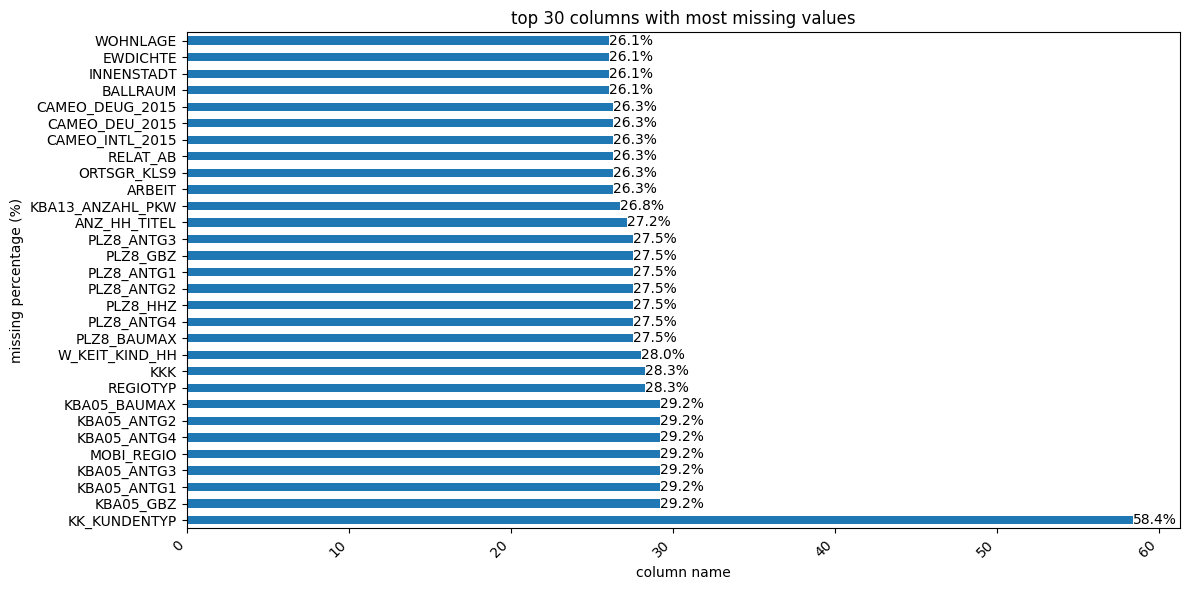

In [102]:
# plot top 30 columns with most missing values

top_missing = missing_pct_cust.sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 6))
ax = top_missing.plot(kind='barh')

# Add values on bars
plt.bar_label(ax.containers[0], fmt='%.1f%%')


plt.xlabel('column name')
plt.ylabel('missing percentage (%)')
plt.title('top 30 columns with most missing values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In the customer dataset there are a lot more missing values than in the azdias dataset. In the azdias dataset i dropped out every columns below 16% missing values. In the customer dataset that would lead to too many dropped out columns

In [103]:
azdias_scaled_df.head(3)

,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GEBURTSJAHR,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SOHO_KZ,VERS_TYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
1,-1.681272,0.957908,-1.494591,1.537914,-1.040682,1.465953,0.958621,1.339323,0.828943,-0.530405,1.010151,0.457885,0.351093,-1.685456,0.443210,-0.059357,0.002829,-0.463912,-1.684495,-1.109916,-1.435374,-0.578163,1.274182,-0.312202,1.339261,-0.157564,1.518701,1.288991,10.854198,0.922936,-1.424288,0.234463,-0.060407,1.026725,-0.578712,0.567336,0.173580,-0.125133,-1.304537,-0.383173,-0.027107,-1.008831,-0.965686,-0.594872,2.730682,2.090507,-1.659277,0.845249,-0.547152,1.701099,-0.799736,-0.551202,-1.279703,0.166964,-0.653056,0.941462,-0.256527,0.211981,0.402976,0.442540,-0.633268,1.455860,0.574312,-0.171823,-0.126856,0.682707,1.016170,-0.530405,1.175656,-1.248888
2,0.169121,0.957908,-1.494591,0.864555,-1.766968,-0.571004,0.244100,1.339323,0.811223,1.885351,1.010151,-0.985547,-0.963997,-0.310906,-0.072007,-1.626998,-0.520592,-0.463912,-0.142547,-0.158742,0.754261,-0.578163,0.064229,1.391982,1.339261,1.448750,-0.638945,-0.410210,-0.092130,-1.083499,0.802120,-0.630194,-0.060407,-0.267567,-0.578712,0.567336,0.109592,-0.125133,1.274838,-0.383173,-1.052996,-0.297914,1.444761,0.408137,-0.464082,-0.749550,-0.116192,-0.986691,0.034489,-0.271090,0.283467,-0.551202,0.092855,-0.476483,-1.148100,0.227085,0.786634,0.211981,-0.623114,-0.934787,-0.633268,0.419750,0.574312,-0.171823,-0.126856,-0.788408,1.016170,1.885351,-0.869679,0.767097
3,1.094317,0.957908,0.683149,-0.482164,1.138177,-0.571004,-1.184941,-0.791197,0.788291,-0.530405,-0.311829,-1.226118,-1.227015,-0.998181,0.443210,-1.626998,-1.044012,-1.509285,-0.142547,-0.158742,1.301669,-0.067374,-0.540747,-0.312202,-0.303545,0.377874,-0.099534,0.156191,-0.092130,-1.083499,0.278260,-1.494851,-0.060407,-2.209004,0.995633,0.567336,-0.466294,-0.125133,0.629994,1.117156,1.511726,1.834835,-0.162203,-0.594872,-0.464082,-0.181538,0.655351,-0.070721,-1.128794,0.715004,0.283467,-2.366472,0.779135,-1.119931,-2.138190,-0.103065,-0.256527,-0.890128,0.402976,-0.934787,-0.633268,-0.616361,0.574312,-1.170253,-0.997197,-0.052850,0.323226,-0.530405,-1.551457,-0.576893


In [104]:
customers.shape

(191652, 85)

In [105]:
customers_clean = clean_data(customers, feat_info)

In [106]:
customers_clean.shape

(191652, 86)

In [107]:
customers_clean.head(3)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
0,2.0,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1.0,20.0,5.0,2.0,2.0,10.0,5.0,1,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3.0,0.0,0.0,1.0,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,7.0,1,1A,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0,50.0,1.0,1.0,3.0
1,NaN,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3.0,0.0,0.0,1.0,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,4,2,2.0,5,1,5,1,4,4,2,0,3.0,1,2.0,13.0,3.0,1.0,1.0,10.0,5.0,1,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,1.0,0.0,0.0,2.0,3,6.0,1.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,8.0,1.0,1992.0,2.0,5,5D,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0,50.0,1.0,3.0,4.0


In [108]:
# columns in customers_clean but not in azdias_scaled_df
customer_col_drop = set(customers_clean.columns) - set(azdias_scaled_df.columns)

In [109]:
customer_col_drop

{'AGER_TYP',
 'CAMEO_DEUG_2015',
 'CAMEO_DEU_2015',
 'CJT_GESAMTTYP',
 'FINANZTYP',
 'GEBAEUDETYP',
 'GFK_URLAUBERTYP',
 'KK_KUNDENTYP',
 'LP_FAMILIE_FEIN',
 'LP_FAMILIE_GROB',
 'LP_STATUS_FEIN',
 'LP_STATUS_GROB',
 'NATIONALITAET_KZ',
 'SHOPPER_TYP',
 'TITEL_KZ',
 'ZABEOTYP'}

In [110]:
# columns in azdias_scaled_df but not in customers_clean
customer_col_drop_n = set(azdias_scaled_df.columns) - set(customers_clean.columns)

In [111]:
print(customer_col_drop_n)

set()


In [112]:
customers_clean.drop(customer_col_drop, axis=1, inplace=True)

In [113]:
print(set(customers_clean.columns) == set(azdias_scaled_df.columns))

True


In [114]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

customers_clean.head(3)

,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GEBURTSJAHR,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SOHO_KZ,VERS_TYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
0,4,1,5,1,5,1,2,2,0,1,1.0,20.0,5.0,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,0.0,1.0,10.0,2.0,0.0,1.0,6.0,9.0,1.0,0.0,5.0,1992.0,7.0,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0,50.0,1.0,1.0,3.0
1,4,1,5,1,5,1,3,2,0,0,1.0,NaN,NaN,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,0.0,1.0,11.0,3.0,0.0,NaN,0.0,9.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,2,5,1,5,1,4,4,0,1,2.0,13.0,3.0,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,0.0,2.0,6.0,1.0,0.0,1.0,6.0,9.0,1.0,0.0,1.0,1992.0,2.0,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0,50.0,1.0,3.0,4.0


In [115]:
# fill missing values
customers_clean.isnull().sum().sum()

2119442

In [116]:
# handle missing values

# store column and index
column_names = customers_clean.columns
index_values = customers_clean.index

# create and fit imputer
imputer = SimpleImputer(strategy='median')
customers_clean = pd.DataFrame(
    imputer.fit_transform(customers_clean),
    columns = column_names,
    index = index_values
)

In [117]:
customers_clean.isnull().sum().sum()

0

In [118]:
# scalling dataset
customers_scaled = scaler.transform(customers_clean)
customers_scaled = pd.DataFrame(customers_scaled, columns=customers_clean.columns.tolist())

# PCA transformation
customers_pca = pca_final.transform(customers_scaled)

In [119]:
# kmeans model fitted on general population
customers_preds = kmeans_final.predict(customers_pca)

print(f"customer predictions using population-fitted model:")
print(f"cluster distribution:\n{pd.Series(customers_preds).value_counts().sort_index()}")

customer predictions using population-fitted model:
cluster distribution:
0     46087
1      9745
2      3305
3      2441
4     23296
5       699
6       720
7      3340
8     43080
9      1003
10     6009
11     2864
12     3647
13     1512
14     1398
15      765
16    15241
17     3482
18     8312
19    11228
20     3478
Name: count, dtype: int64


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

In [120]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

In [121]:
# count samples in each cluster

CLUSTER COMPARISON: General Population vs. Customers
 Cluster  Population_Count  Population_Pct  Customer_Count  Customer_Pct  Difference_Pct    Ratio
       0             43742        5.480966           46087     24.047231       18.566265 4.387408
       1             58587        7.341076            9745      5.084737       -2.256339 0.692642
       2             29698        3.721223            3305      1.724480       -1.996743 0.463418
       3             45424        5.691724            2441      1.273663       -4.418061 0.223774
       4             58126        7.283312           23296     12.155365        4.872053 1.668934
       5             46708        5.852612             699      0.364724       -5.487889 0.062318
       6             49794        6.239294             720      0.375681       -5.863614 0.060212
       7             43467        5.446508            3340      1.742742       -3.703766 0.319974
       8             46981        5.886820           43080     22

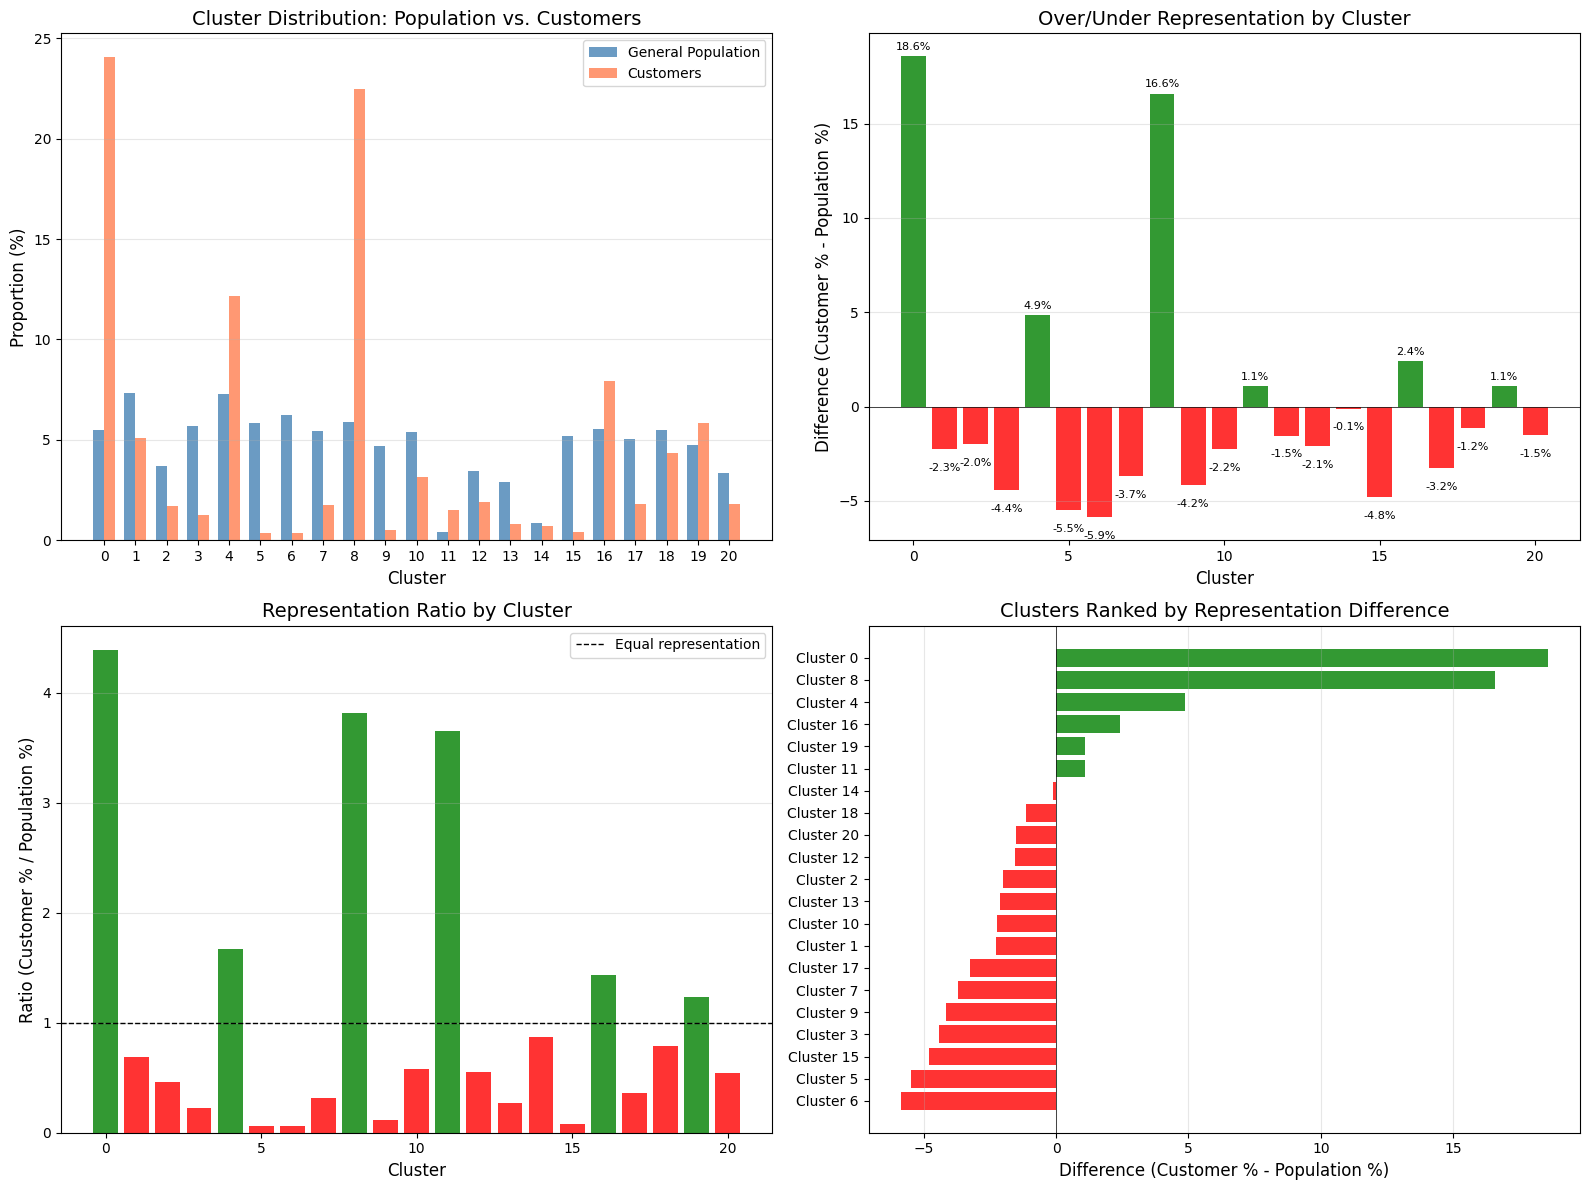

OVERREPRESENTED CLUSTERS (Target Audience)
 Cluster  Population_Pct  Customer_Pct  Difference_Pct    Ratio
       0        5.480966     24.047231       18.566265 4.387408
       8        5.886820     22.478242       16.591422 3.818402
       4        7.283312     12.155365        4.872053 1.668934
      16        5.548128      7.952435        2.404307 1.433355
      19        4.765365      5.858535        1.093170 1.229399
      11        0.408861      1.494375        1.085514 3.654973
UNDERREPRESENTED CLUSTERS (Non-Target)
 Cluster  Population_Pct  Customer_Pct  Difference_Pct    Ratio
       6        6.239294      0.375681       -5.863614 0.060212
       5        5.852612      0.364724       -5.487889 0.062318
      15        5.206930      0.399161       -4.807769 0.076660
       3        5.691724      1.273663       -4.418061 0.223774
       9        4.685799      0.523344       -4.162454 0.111687
       7        5.446508      1.742742       -3.703766 0.319974
      17        5.0619

In [122]:
# general population proportions
pop_cluster_counts = pd.Series(azdias_clusters).value_counts().sort_index()
pop_proportions = pop_cluster_counts / len(azdias_clusters) * 100

# customer proportions
cust_cluster_counts = pd.Series(customers_preds).value_counts().sort_index()
cust_proportions = cust_cluster_counts / len(customers_preds) * 100

# comparison DataFrame
comparison_df = pd.DataFrame({
    'Cluster': range(n_clusters_selected),
    'Population_Count': pop_cluster_counts.values,
    'Population_Pct': pop_proportions.values,
    'Customer_Count': cust_cluster_counts.reindex(range(n_clusters_selected), fill_value=0).values,
    'Customer_Pct': cust_proportions.reindex(range(n_clusters_selected), fill_value=0).values
})

# calculation of difference and ratio
comparison_df['Difference_Pct'] = comparison_df['Customer_Pct'] - comparison_df['Population_Pct']
comparison_df['Ratio'] = comparison_df['Customer_Pct'] / comparison_df['Population_Pct']

print("CLUSTER COMPARISON: General Population vs. Customers")
print(comparison_df.to_string(index=False))



# visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# plot 1: side-by-side bar chart
ax1 = axes[0, 0]
x = np.arange(n_clusters_selected)
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Population_Pct'], width, 
                label='General Population', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_df['Customer_Pct'], width, 
                label='Customers', color='coral', alpha=0.8)

ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Proportion (%)', fontsize=12)
ax1.set_title('Cluster Distribution: Population vs. Customers', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels([str(i) for i in range(n_clusters_selected)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# plot 2: difference plot (customer % - population %)
ax2 = axes[0, 1]
colors = ['green' if d > 0 else 'red' for d in comparison_df['Difference_Pct']]
bars = ax2.bar(comparison_df['Cluster'], comparison_df['Difference_Pct'], color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Difference (Customer % - Population %)', fontsize=12)
ax2.set_title('Over/Under Representation by Cluster', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# add value labels
for bar, val in zip(bars, comparison_df['Difference_Pct']):
    height = bar.get_height()
    ax2.annotate(f'{val:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -10),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=8)

# plot 3: ratio plot
ax3 = axes[1, 0]
colors_ratio = ['green' if r > 1 else 'red' for r in comparison_df['Ratio']]
ax3.bar(comparison_df['Cluster'], comparison_df['Ratio'], color=colors_ratio, alpha=0.8)
ax3.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Equal representation')
ax3.set_xlabel('Cluster', fontsize=12)
ax3.set_ylabel('Ratio (Customer % / Population %)', fontsize=12)
ax3.set_title('Representation Ratio by Cluster', fontsize=14)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# plot 4: sorted difference for easy identification
ax4 = axes[1, 1]
sorted_df = comparison_df.sort_values('Difference_Pct', ascending=True)
colors_sorted = ['green' if d > 0 else 'red' for d in sorted_df['Difference_Pct']]
ax4.barh(range(len(sorted_df)), sorted_df['Difference_Pct'], color=colors_sorted, alpha=0.8)
ax4.set_yticks(range(len(sorted_df)))
ax4.set_yticklabels([f"Cluster {int(c)}" for c in sorted_df['Cluster']])
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_xlabel('Difference (Customer % - Population %)', fontsize=12)
ax4.set_title('Clusters Ranked by Representation Difference', fontsize=14)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# identify over- and underrepresented clusters

print("OVERREPRESENTED CLUSTERS (Target Audience)")
overrep = comparison_df[comparison_df['Difference_Pct'] > 1].sort_values('Difference_Pct', ascending=False)
print(overrep[['Cluster', 'Population_Pct', 'Customer_Pct', 'Difference_Pct', 'Ratio']].to_string(index=False))

print("UNDERREPRESENTED CLUSTERS (Non-Target)")
underrep = comparison_df[comparison_df['Difference_Pct'] < -1].sort_values('Difference_Pct', ascending=True)
print(underrep[['Cluster', 'Population_Pct', 'Customer_Pct', 'Difference_Pct', 'Ratio']].to_string(index=False))

In [131]:
# interpret cluster characteristics using inverse transform

def interpret_cluster(cluster_id, kmeans_model, pca_model, scaler_model, feature_names, top_n=10):

    # get cluster centroid in PCA space
    centroid_pca = kmeans_model.cluster_centers_[cluster_id].reshape(1, -1)
    
    # inverse PCA transform
    centroid_scaled = pca_model.inverse_transform(centroid_pca)
    
    # inverse scaling
    centroid_original = scaler_model.inverse_transform(centroid_scaled)
    
    # DataFrame with feature values
    centroid_df = pd.DataFrame({
        'Feature': feature_names,
        'Value': centroid_original.flatten()
    })
    
    # sort by absolute value to find most extreme features
    centroid_df['Abs_Value'] = centroid_df['Value'].abs()
    centroid_df = centroid_df.sort_values('Abs_Value', ascending=False)
    
    return centroid_df.head(top_n)

# get feature names
feature_names = customers_clean.columns.tolist()

# analyze top overrepresented cluster
if len(overrep) > 0:
    top_overrep_cluster = int(overrep.iloc[0]['Cluster'])
    print(f"TOP OVERREPRESENTED CLUSTER: {top_overrep_cluster}")
    print(f"this cluster represents {overrep.iloc[0]['Customer_Pct']:.1f}% of customers")
    print(f"but only {overrep.iloc[0]['Population_Pct']:.1f}% of general population")
    print(f"\nkey characteristics (top features):")
    top_features = interpret_cluster(top_overrep_cluster, kmeans_final, pca_final, scaler, feature_names)
    print(top_features.to_string(index=False))

# analyze top underrepresented cluster
if len(underrep) > 0:
    top_underrep_cluster = int(underrep.iloc[0]['Cluster'])
    print(f"TOP UNDERREPRESENTED CLUSTER: {top_underrep_cluster}")
    print(f"this cluster represents only {underrep.iloc[0]['Customer_Pct']:.1f}% of customers")
    print(f"but {underrep.iloc[0]['Population_Pct']:.1f}% of general population")
    print(f"\nkey characteristics (top features):")
    bottom_features = interpret_cluster(top_underrep_cluster, kmeans_final, pca_final, scaler, feature_names)
    print(bottom_features.to_string(index=False))


TOP OVERREPRESENTED CLUSTER: 0
this cluster represents 24.0% of customers
but only 5.5% of general population

key characteristics (top features):
                     Feature       Value   Abs_Value
            MIN_GEBAEUDEJAHR 1993.375837 1993.375837
                 GEBURTSJAHR 1317.460880 1317.460880
            KBA13_ANZAHL_PKW  676.294128  676.294128
PRAEGENDE_JUGENDJAHRE_DECADE   86.605417   86.605417
         LP_LEBENSPHASE_FEIN   15.162949   15.162949
                    ALTER_HH   12.557452   12.557452
              WOHNDAUER_2008    7.519008    7.519008
               SEMIO_PFLICHT    6.184116    6.184116
                   SEMIO_RAT    6.126633    6.126633
                  INNENSTADT    5.905395    5.905395
TOP UNDERREPRESENTED CLUSTER: 6
this cluster represents only 0.4% of customers
but 6.2% of general population

key characteristics (top features):
                     Feature       Value   Abs_Value
            MIN_GEBAEUDEJAHR 1992.581265 1992.581265
                 

### Discussion 3.3: Compare Customer Data to Demographics Data


Cluster 0 is overrepresented in the clusters:
this cluster represents 24.0% of customers
but only 5.5% of general population

Here we can see the the customers, who are relatively popular for product of the mail company.
The customers are for example a little older, are living closer to the city centre and single homeowner or couples.


Cluster 6 is underrepresented in the clusters:
this cluster represents only 0.4% of customers
but 6.2% of general population

The underrepresented customers are a little younger, single and are living in buildings with more number of households.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.